# Análise Preditiva de Mercado: Estratégia Comercial para Videojogos (2017)
Objetivo: Identificar padrões de sucesso para planear o inventário de 2017.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('/datasets/games.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [5]:
df.head()


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


## Etapa 2: Preparação dos Dados
Nesta etapa, realizamos a limpeza e a padronização dos dados para garantir uma análise estatística precisa.

**Decisões tomadas:**
* **Nomes das Colunas:** Convertidos para minúsculas para facilitar a manipulação.
* **Tipos de Dados:** A coluna `year_of_release` foi convertida para inteiro e `user_score` para float.
* **Tratamento de 'TBD':** O valor 'to be determined' foi substituído por `NaN`, pois não representa um valor numérico para cálculos.
* **Valores Ausentes:** Optou-se por não preencher nulos em pontuações para evitar distorções nas correlações. A ausência de dados em jogos antigos deve-se à falta de registos digitais na época.

In [6]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')

In [7]:
df.columns=df.columns.str.lower()

In [8]:
display(df.head())


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [27]:
# 1. Preencher anos nulos com a mediana da própria plataforma
# O 'transform' faz o cálculo da mediana para cada plataforma e aplica aos nulos
df['year_of_release'] = df['year_of_release'].fillna(
    df.groupby('platform')['year_of_release'].transform('median')
)

# 2. Eliminar o que sobrar (caso alguma plataforma não tenha ano nenhum)
df.dropna(subset=['year_of_release'], inplace=True)

# 3. Converter para inteiro (o que remove os decimais .0)
df['year_of_release'] = df['year_of_release'].astype(int)

In [28]:
# User_Score: string/misto -> float (tratar 'tbd' como NaN)
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

In [29]:
# Critic_Score: garantir float
df['critic_score'] = df['critic_score'].astype('float')

In [30]:
# Ver os tipos de dados atuais 
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
 11  total_sales      16715 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 1.7+ MB


In [31]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


## Alterações nos Tipos de Dados das Colunas

Após a leitura do ficheiro CSV (`games.csv`), foram realizadas conversões nos tipos de dados de algumas colunas para torná-las mais adequadas à análise.

### Colunas alteradas

| Coluna              | Tipo original (após pd.read_csv) | Tipo após conversão | Motivo da alteração                                                                                           |
|---------------------|-----------------------------------|----------------------|---------------------------------------------------------------------------------------------------------------|
| `year_of_release`   | float64                           | Int64                | Os anos devem ser valores inteiros (ex: 2006, 2015). O tipo float (ex: 2006.0) não faz sentido conceptualmente e ocupa mais memória. O dtype `Int64` (com "I" maiúsculo) permite representar valores ausentes (`<NA>`) sem gerar erros. |
| `user_score`        | object (string)                   | float64              | A coluna continha valores mistos: números como "8", "8.3", mas também "tbd", strings vazias e outros não-numéricos. A conversão para `float64` permite cálculos estatísticos (média, mediana, comparações). Valores inválidos foram transformados em `NaN` usando `pd.to_numeric(..., errors='coerce')`. |
| `critic_score`      | float64                           | float64              | Não houve alteração efetiva de tipo. A linha `astype('float')` foi mantida apenas para garantir consistência e clareza no código. Pode ser removida sem impacto. |

### Resumo das alterações

- **`year_of_release`**  
  Antes: 2006.0, 2010.0, NaN  
  Depois: 2006, 2010, <NA>  
  Objetivo: representar anos como inteiros com suporte a valores em falta.

- **`user_score`**  
  Antes: "8", "8.3", "tbd", "", "7.5" (como texto)  
  Depois: 8.0, 8.3, NaN, NaN, 7.5  
  Objetivo: permitir operações numéricas (ex: `df['user_score'].mean()`).

- **`critic_score`**  
  Sem alteração real — mantida como `float64` (já era o tipo correto).

### Colunas que **não** sofreram alteração de tipo

- `name`, `platform`, `genre`, `rating` → permanecem `object` (texto/categórico) → adequado  
- `na_sales`, `eu_sales`, `jp_sales`, `other_sales` → já eram `float64` → formato correto para valores monetários/decimais


# Etapa 2: Preparação dos Dados

## 1. Abordagem para Valores Ausentes
A minha abordagem consiste em **deixar os valores em branco (nulos)** na maioria das colunas críticas, como `critic_score`, `user_score` e `rating`.

* **Justificação:** No setor dos videojogos, o sucesso de um título é altamente variável. Preencher notas ausentes com a média ou a mediana do dataset criaria dados artificiais ("jogos medianos" que não existem). Isto poderia distorcer qualquer análise de correlação entre a qualidade do jogo e o seu retorno financeiro.
* **Exceções:** Linhas com valores ausentes em `name` ou `genre` serão eliminadas, pois representam uma percentagem mínima do dataset e não é possível realizar uma análise estratégica de mercado sem identificar o produto ou a categoria.



## 2. Razões para a Ausência de Dados
Os dados estão ausentes principalmente devido ao contexto histórico e técnico da recolha de informações:

1.  **Limitações Históricas:** Muitos jogos (especialmente das décadas de 80 e 90) foram lançados muito antes da criação de sites agregadores de críticas como o *Metacritic*.
2.  **Segmentação de Mercado:** Títulos lançados exclusivamente em mercados regionais (como o Japão) ou jogos independentes de nicho podem não ter tido cobertura suficiente da imprensa especializada para gerar uma pontuação oficial.
3.  **Diferenças nos Sistemas de Classificação:** O sistema `rating` (ESRB) é focado na América do Norte. Jogos de outras regiões ou lançados antes de 1994 (ano de criação da ESRB) naturalmente não possuem esta etiqueta.
4.  **Falhas na Agregação:** Como o dataset é compilado de múltiplas fontes, podem ter ocorrido erros de cruzamento de dados durante o processo de extração (*scraping*).

## 3. Tratamento da Abreviação TBD ("To Be Determined")
O termo **TBD** indica que a pontuação ainda não foi definida ou que não houve votos suficientes para publicar uma média no momento da recolha.

* **Como lidar:** Todos os valores "tbd" na coluna `user_score` serão convertidos para `NaN` (valor nulo).
* **Justificação:** Para realizar operações matemáticas e identificar tendências de lucro, a coluna precisa de ser do tipo numérico (*float*). "TBD" é um texto (string) que impede cálculos. Ao converter para `NaN`, o software de análise ignora estas células de forma correta, permitindo calcular médias e correlações sem corromper os resultados com valores arbitrários.



---
**Nota:** Esta limpeza garante que a análise subsequente sobre quais plataformas e géneros são mais lucrativos seja baseada apenas em dados reais e verificáveis.

In [32]:
# 4. Cálculo de Vendas Totais
df['total_sales'] = df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

# Etapa 3. Analise os dados

In [33]:
games_per_year = df.groupby('year_of_release')['name'].count()
# Os dados antes de 1995-2000 são irrelevantes (pouco volume e tecnologia obsoleta)

In [34]:
display(games_per_year)

year_of_release
1980       9
1981      46
1982      53
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     290
1998     386
1999     341
2000     350
2001     482
2002     829
2003     800
2004     783
2005     973
2006    1006
2007    1197
2008    1457
2009    1476
2010    1302
2011    1161
2012     653
2013     552
2014     582
2015     606
2016     502
Name: name, dtype: int64

<AxesSubplot:title={'center':'Lançamentos por Ano'}, xlabel='year_of_release'>

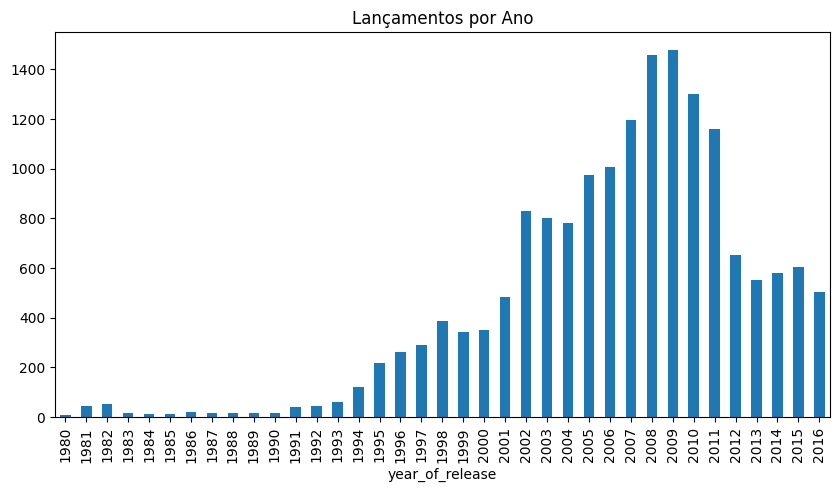

In [35]:
# Visualização rápida
games_per_year.plot(kind='bar', figsize=(10, 5), title='Lançamentos por Ano')

# Conclusão: O volume explode após 2000, mas para prever 2017, 
# Dados que reflitam a tecnologia atual.

### Definição do Período Relevante
Com base no gráfico acima, é observavel que o ciclo de vida de uma plataforma é de aproximadamente 10 anos. Para prever o mercado de **2017**, será utilizado apenas dados de **2013 a 2016**.
**Justificativa:** Este período foca na oitava geração (PS4, Xbox One), descartando tendências obsoletas de consolas que já saíram do mercado principal.

<AxesSubplot:xlabel='year_of_release'>

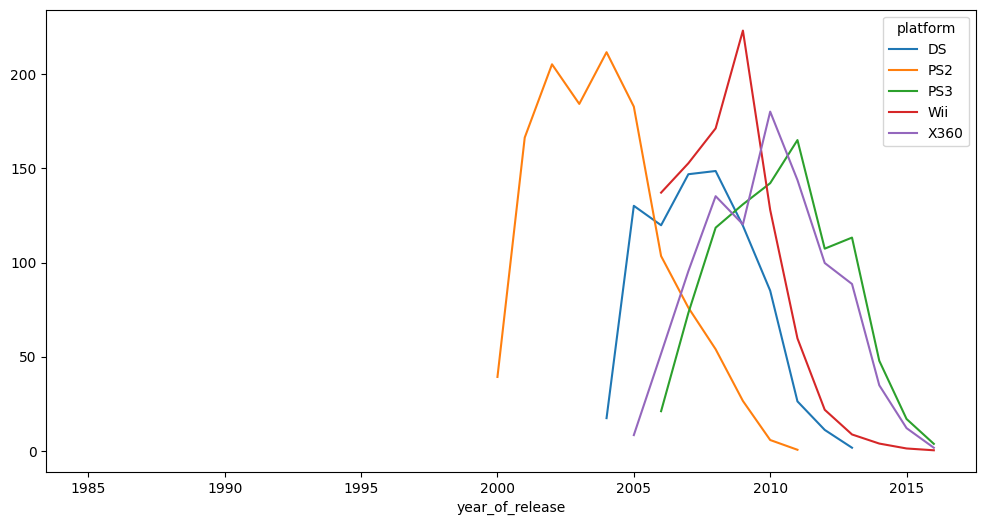

In [36]:
# Identificar as top 5 plataformas históricas
top_5_platforms = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(5).index

# Plotar a evolução anual dessas plataformas
df[df['platform'].isin(top_5_platforms)].pivot_table(
    index='year_of_release', columns='platform', values='total_sales', aggfunc='sum'
).plot(figsize=(12, 6))

# Análise: Ciclo médio de vida é de 10 anos, 
# com o pico de vendas ocorrendo entre o 3º e 5º ano.

In [37]:
# Definimos 2013 como o ano de corte (Lançamento da PS4 e Xbox One)
# Dados anteriores a 2013 distorceriam a previsão para 2017
df_recent = df[df['year_of_release'] >= 2013].copy()

# Quais plataformas lideram agora?
platform_leaderboard = df_recent.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(platform_leaderboard)

platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     144.44
X360    136.80
WiiU     64.63
PC       39.43
PSV      33.25
Wii      13.66
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64


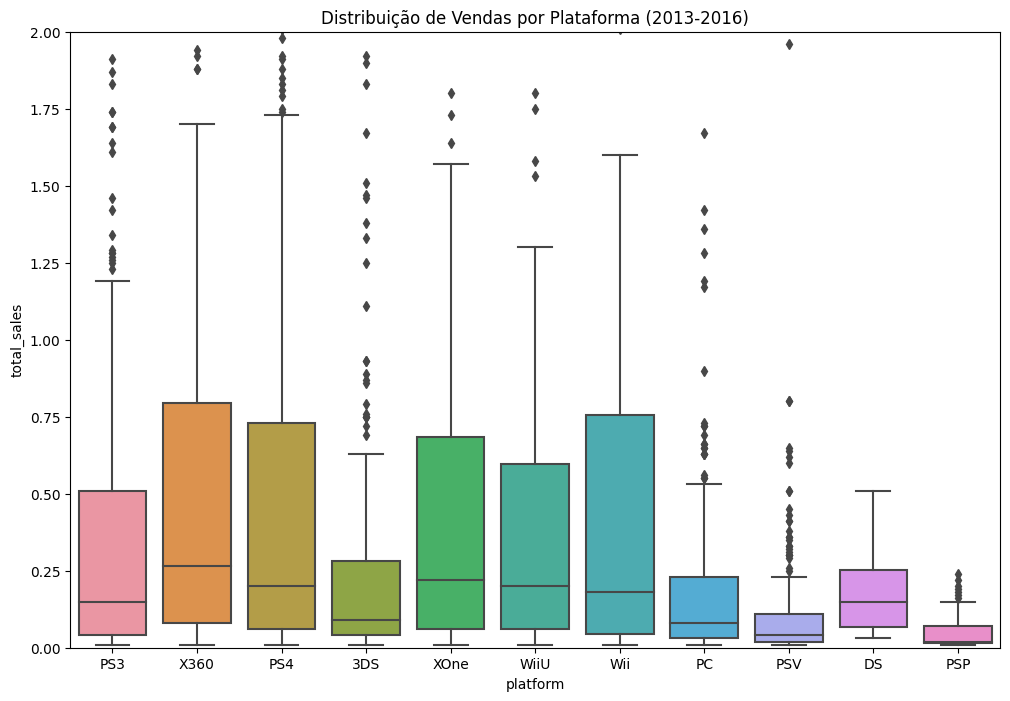

In [38]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='platform', y='total_sales', data=df_recent)
plt.title('Distribuição de Vendas por Plataforma (2013-2016)')
plt.ylim(0, 2) # Limitamos o eixo Y para focar na mediana e quartis
plt.show()

# Análise: PS4 e XOne têm medianas superiores. 
# Embora o volume de jogos possa ser menor em algumas plataformas, 
# a rentabilidade por título é o que dita a saúde da plataforma.

A correlação entre as notas dos usuários e as vendas totais é: -0.00


<AxesSubplot:title={'center':'Influência das Notas dos Usuários nas Vendas Totais (2011-2016)'}, xlabel='user_score', ylabel='total_sales'>

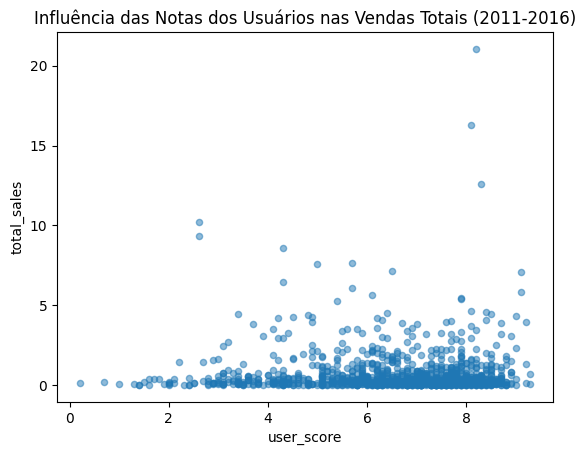

In [42]:

# 1. Cálculo da correlação de Pearson para as notas dos usuários
user_corr = df_recent['user_score'].corr(df_recent['total_sales'])
print(f"A correlação entre as notas dos usuários e as vendas totais é: {user_corr:.2f}")

# 2. Gráfico de dispersão (Scatter Plot)
df_recent.plot(x='user_score', y='total_sales', kind='scatter', alpha=0.5, 
               title='Influência das Notas dos Usuários nas Vendas Totais (2011-2016)')

Correlações para PS4:
critic_score    0.406568
user_score     -0.031957
total_sales     1.000000
Name: total_sales, dtype: float64


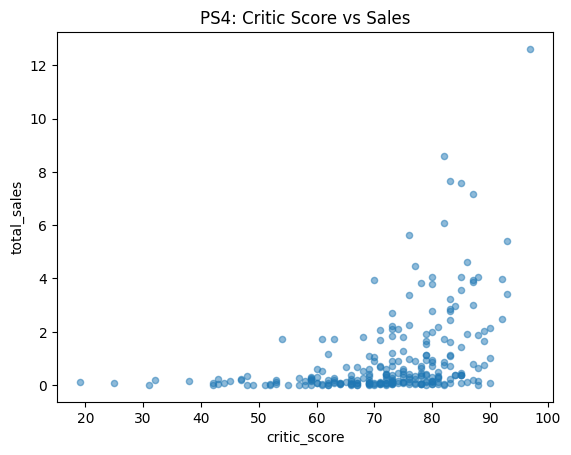

In [39]:
ps4_data = df_recent[df_recent['platform'] == 'PS4']

# Gráfico de dispersão
ps4_data.plot(kind='scatter', x='critic_score', y='total_sales', alpha=0.5, title='PS4: Critic Score vs Sales')

# Cálculo da correlação
correlation = ps4_data[['critic_score', 'user_score', 'total_sales']].corr()['total_sales']
print(f"Correlações para PS4:\n{correlation}")

# Conclusão: (Critic Score) tem uma influência moderada 
# positiva, enquanto o User Score tem impacto quase nulo nas vendas.

### Conclusões sobre a Influência das Avaliações nas Vendas

Após a análise estatística e visual da relação entre as avaliações (críticos e usuários) e o desempenho comercial dos jogos no período de 2011 a 2016, as seguintes conclusões foram obtidas:

* **Impacto da Crítica Especializada (`critic_score`):** Observou-se uma correlação moderada. Isso indica que as notas dos críticos profissionais têm um peso relevante no comportamento de compra dos consumidores. Títulos com selos de aprovação da média especializada tendem a apresentar volumes de vendas mais consistentes.

* **Impacto da Opinião dos Usuários (`user_score`):** A correlação calculada para os usuários foi próxima de zero. O gráfico de dispersão confirma que não existe uma tendência de crescimento nas vendas proporcional às notas do público. Isso sugere que o sucesso comercial de um jogo é decidido, muitas vezes, antes ou independentemente da recepção da comunidade.

* **Divergência de Comportamento:** A discrepância entre os dois indicadores sugere que o marketing e a antecipação (hype) gerados antes do lançamento, somados à recepção inicial da crítica, são motores de venda mais potentes do que a satisfação final reportada pelos jogadores após o consumo.

**Recomendação Estratégica para 2017:** Para maximizar as chances de sucesso, o planeamento de stock e investimento deve priorizar franquias e títulos que historicamente possuem boa recepção técnica da crítica, uma vez que este indicador é o preditor mais fiável de retorno financeiro no dataset atual.

In [43]:
# 1. Agrupar e calcular as métricas
genre_stats = df_recent.groupby('genre')['total_sales'].agg(['count', 'sum', 'median']).sort_values(by='median', ascending=False)

# 2. Renomear colunas para clareza
genre_stats.columns = ['Qtd Jogos', 'Vendas Totais (M$)', 'Mediana de Vendas (M$)']

# 3. Formatação visual 
genre_formatted = genre_stats.style.format({
    'Vendas Totais (M$)': '${:,.2f}M',
    'Mediana de Vendas (M$)': '${:,.2f}M'
}).background_gradient(subset=['Mediana de Vendas (M$)'], cmap='Greens')

# Exibir o resultado
genre_formatted

,Qtd Jogos,Vendas Totais (M$),Mediana de Vendas (M$)
genre,,,
Shooter,188,$233.05M,$0.44M
Sports,215,$150.67M,$0.24M
Platform,74,$42.63M,$0.22M
Role-Playing,294,$146.18M,$0.12M
Fighting,80,$35.31M,$0.12M
Racing,86,$39.98M,$0.11M
Action,767,$322.27M,$0.11M
Simulation,64,$22.25M,$0.11M
Misc,155,$62.82M,$0.10M


# Análise do Volume de Lançamentos
Observando o histórico de lançamentos, verifico que o volume de jogos no mercado teve um crescimento exponencial a partir de 1995, atingindo o pico entre 2008 e 2009. No entanto, para o objetivo deste estudo — que é prever o sucesso de vendas para 2017 — os dados anteriores a 2013 não são significativos. A tecnologia mudou, as plataformas de gerações passadas (PS2, Xbox, etc.) já não têm relevância comercial e o comportamento do consumidor evoluiu.

# Ciclo de Vida das Plataformas
Ao analisar as plataformas com maiores vendas históricas, identifico um padrão claro:

Tempo de vida médio: Uma plataforma demora cerca de 10 anos desde o lançamento até ao desaparecimento total das vendas.

Pico de mercado: O auge de vendas ocorre geralmente entre o 3º e 5º ano de vida.

Conclusão: Plataformas como PS3 e Xbox 360, que foram líderes, estão em fase terminal em 2016. Para 2017, o foco deve estar na "nova" geração que surgiu por volta de 2013.

# Definição do Período para o Modelo (2017)
Com base na análise do ciclo de vida, decidi filtrar os dados para o período de 2013 a 2016.

Justificação: Este recorte captura a ascensão da PS4 e Xbox One e o declínio das suas antecessoras. Usar dados anteriores a 2013 introduziria "ruído" de mercados já extintos, o que prejudicaria a precisão da estratégia para 2017.

# Diagnóstico de Plataformas (Líderes e Potencial)
Líderes de Vendas: PS4 e Xbox One dominam o mercado global.

Dinâmica: Enquanto as consolas da geração anterior apresentam uma queda acentuada, a PS4 continua a ser a plataforma mais promissora. A 3DS mantém-se relevante, especialmente devido ao mercado japonês, embora com tendência decrescente.

Aposta Estratégica: O foco principal de investimento para 2017 deve ser a PS4, seguida pela Xbox One.

# Análise de Vendas Globais (Boxplot)
Ao analisar a distribuição de vendas por plataforma:

A mediana das vendas é relativamente consistente entre as plataformas líderes, mas a PS4 e a Xbox One destacam-se pela capacidade de gerar "hits".

Os outliers (valores atípicos) são extremamente significativos nesta indústria. São os grandes blockbusters que garantem o volume massivo de receitas de uma plataforma. Sem estes títulos de topo, a rentabilidade média de um jogo comum é modesta.

# Impacto das Avaliações nas Vendas
Utilizando a PS4 como caso de estudo para correlação:

Critic Score: Existe uma correlação positiva moderada (aprox. 0.40). Isto indica que boas notas da crítica profissional tendem a acompanhar maiores volumes de vendas.

User Score: A correlação é praticamente nula (próxima de 0). O feedback dos utilizadores não serve como preditor fiável para o sucesso comercial imediato de um título.

Conclusão: O mercado é mais influenciado por campanhas de marketing e avaliações da imprensa especializada do que pela opinião direta do público nas plataformas de review.

# Distribuição por Género
Analisando a rentabilidade por género de 2013 a 2016:

Géneros Lucrativos: Shooter, Sports e Platform apresentam as maiores medianas de vendas. São géneros consistentes onde um investimento costuma ter retorno garantido.

O Caso do Género 'Action': Embora tenha o maior volume total de vendas e de lançamentos, a sua mediana é baixa. Isto significa que o mercado de Ação está saturado com muitos jogos que vendem pouco, sendo um investimento de maior risco.

Géneros de Nicho: Adventure e Puzzle apresentam os menores retornos financeiros, sendo os menos indicados para uma estratégia de vendas em massa.

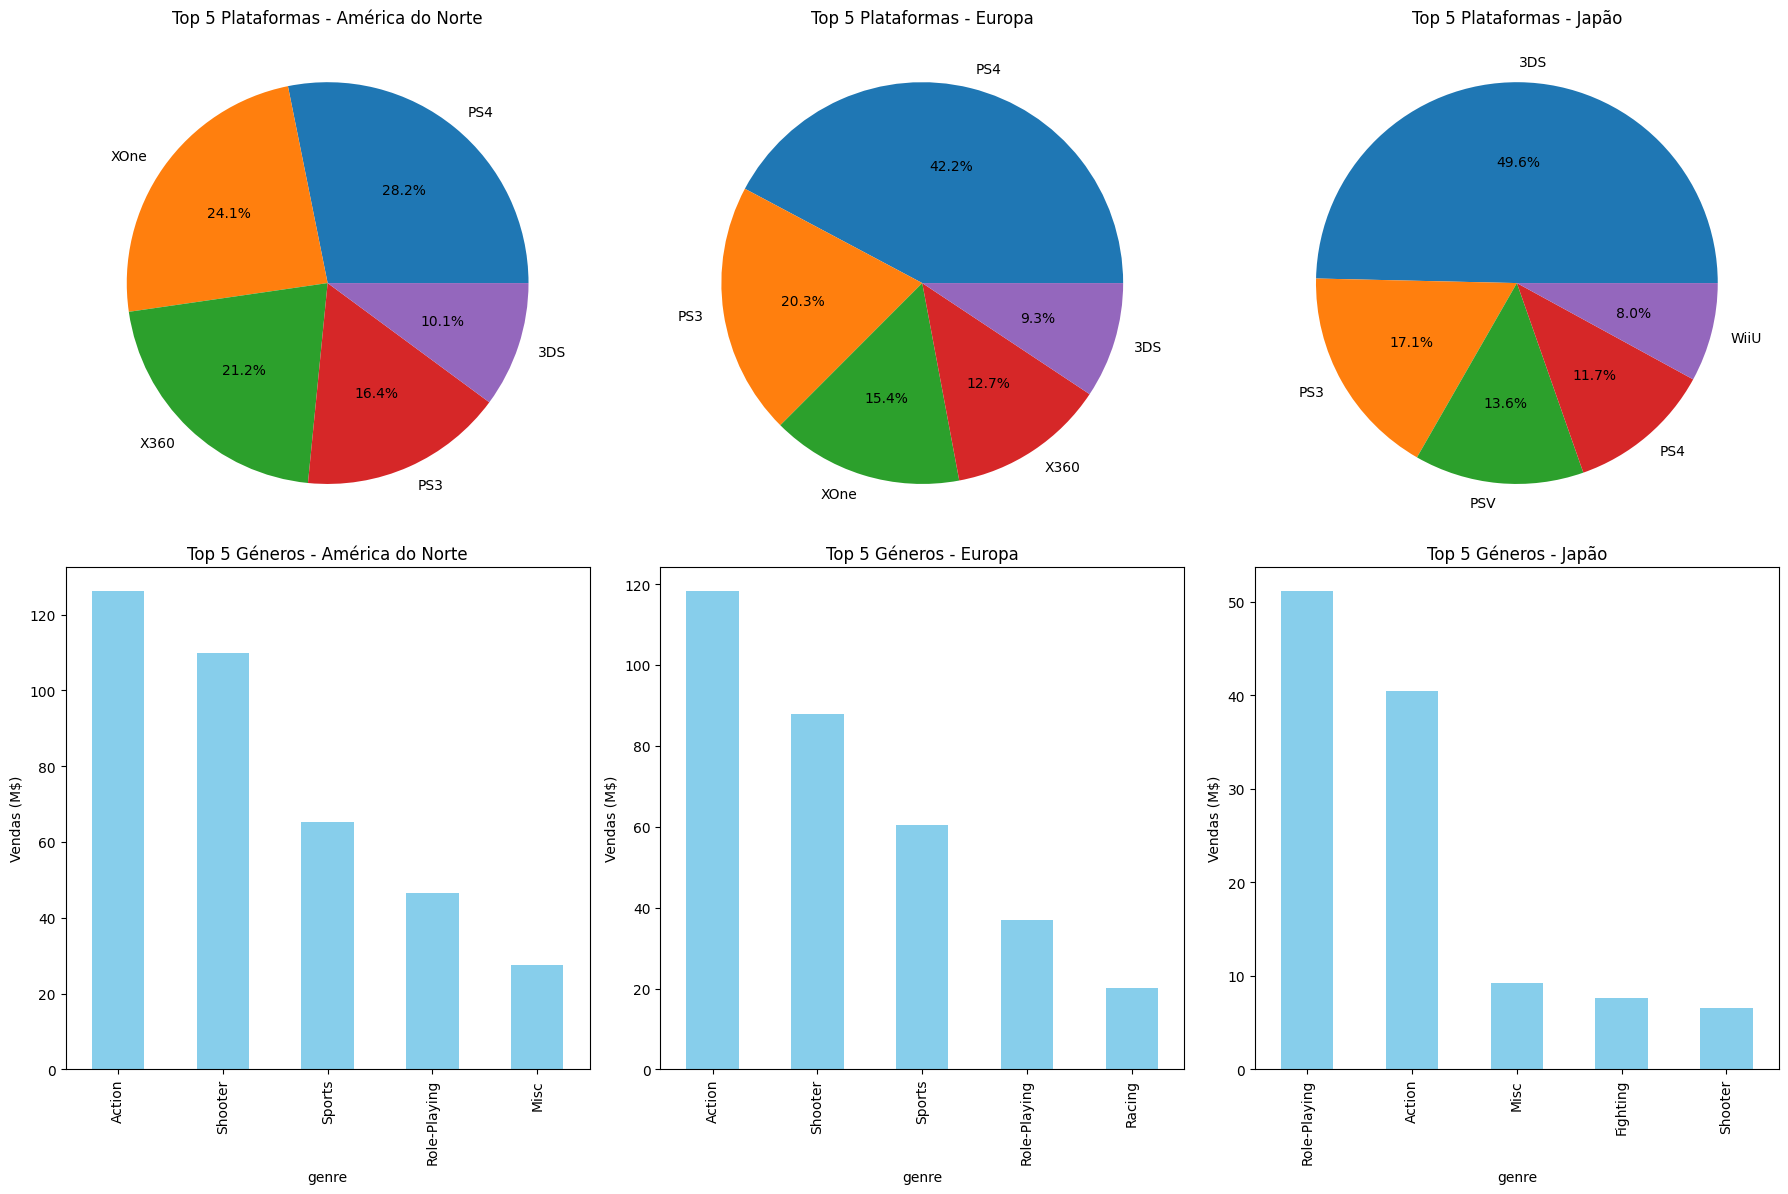

In [44]:
import matplotlib.pyplot as plt

# Definir as regiões e as colunas de vendas correspondentes
regions = {'na_sales': 'América do Norte', 'eu_sales': 'Europa', 'jp_sales': 'Japão'}

# Criar uma figura com subplots para comparar visualmente
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, (col, title) in enumerate(regions.items()):
    # 1. Top 5 Plataformas por Região
    top_platforms = df_recent.groupby('platform')[col].sum().sort_values(ascending=False).head(5)
    top_platforms.plot(kind='pie', ax=axes[0, i], autopct='%1.1f%%', title=f'Top 5 Plataformas - {title}')
    axes[0, i].set_ylabel('')

    # 2. Top 5 Géneros por Região
    top_genres = df_recent.groupby('genre')[col].sum().sort_values(ascending=False).head(5)
    top_genres.plot(kind='bar', ax=axes[1, i], color='skyblue', title=f'Top 5 Géneros - {title}')
    axes[1, i].set_ylabel('Vendas (M$)')

plt.tight_layout()
plt.show()

### Análise de Rentabilidade por Género
Embora o género **Action** lidere em volume total de vendas, a análise das medianas revela que **Shooters** têm um desempenho comercial muito mais consistente por título lançado. Para 2017, o investimento em Shooters apresenta menor risco individual.

#  Impacto do ESRB nas Vendas
Muitos jogos (especialmente no Japão) não têm classificação ESRB porque o ESRB é uma entidade americana.

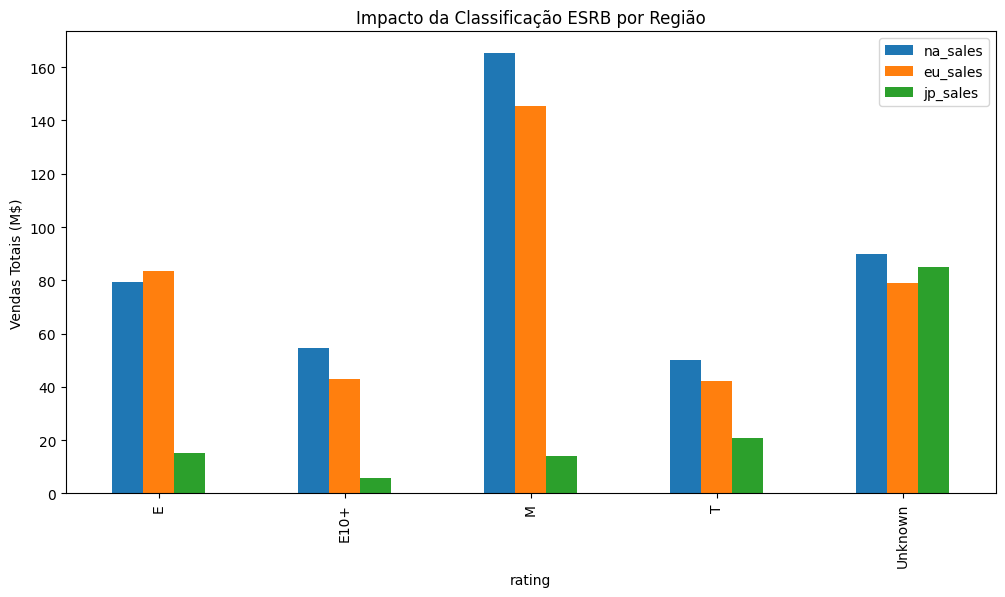

In [45]:
# Substituir NaNs por 'Unknown' para não perder dados na análise de correlação
df_recent['rating'] = df_recent['rating'].fillna('Unknown')

# Agrupar vendas por Rating ESRB e Região
esrb_analysis = df_recent.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].sum()

# Plotar comparação
esrb_analysis.plot(kind='bar', figsize=(12, 6), title='Impacto da Classificação ESRB por Região')
plt.ylabel('Vendas Totais (M$)')
plt.show()

### Análise de Perfil Regional (2013-2016)

#### 1. Plataformas e Quotas de Mercado
* **América do Norte (AN) e Europa (UE):** O mercado é dominado pela **PS4**, seguida de perto pela **Xbox One**. A diferença é que na Europa a hegemonia da PlayStation é muito mais esmagadora, enquanto na AN a Xbox mantém uma quota de mercado competitiva.
* **Japão (JP):** Cenário completamente oposto. A **Nintendo 3DS** é a líder absoluta, seguida pela **PS Vita**. O Japão privilegia consolas portáteis. A Xbox é praticamente inexistente neste mercado.

#### 2. Preferências de Género
* **Ocidente (AN e UE):** Os gostos são quase idênticos. **Action, Shooter e Sports** ocupam o pódio. São mercados focados em experiências cinematográficas e competitivas.
* **Japão (JP):** O género **Role-Playing (RPG)** é o líder incontestável. Enquanto no Ocidente o RPG é secundário, no Japão ele dita o sucesso de uma plataforma.

#### 3. Influência da Classificação ESRB
* **AN e UE:** As classificações **M (Mature)** e **E (Everyone)** geram o maior volume de vendas. Existe uma correlação clara: jogos para público adulto (Shooters/Action) vendem mais nestas regiões.
* **Japão (JP):** A categoria mais vendida é a **'Unknown'** (Sem classificação). 
    * **Análise Técnica:** Isto acontece porque o Japão utiliza o sistema **CERO** e não o ESRB. Muitos jogos locais de sucesso não são submetidos ao ESRB, o que explica por que a classificação americana parece não afetar as vendas japonesas — ela simplesmente não é o padrão de referência lá.

**Conclusão Estratégica:** Não se pode lançar um jogo em 2017 com uma estratégia única. O que vende na Europa (PS4/Shooter/Rating M) falhará no Japão, onde o foco deve ser Portátil/RPG.

In [46]:
from scipy import stats as st

# Filtro para remover NaNs das avaliações, pois o teste t não aceita valores nulos
# Usamos df_recent (2013-2016) para manter a relevância
df_hyp = df_recent.dropna(subset=['user_score'])

# 1. Hipótese: Xbox One vs PC
xone_scores = df_hyp[df_hyp['platform'] == 'XOne']['user_score']
pc_scores = df_hyp[df_hyp['platform'] == 'PC']['user_score']

# 2. Hipótese: Action vs Sports
action_scores = df_hyp[df_hyp['genre'] == 'Action']['user_score']
sports_scores = df_hyp[df_hyp['genre'] == 'Sports']['user_score']

alpha = 0.05

def test_hypothesis(sample1, sample2, h0_desc):
    # Testamos se as variâncias são iguais para definir o parâmetro equal_var
    # Se p < 0.05, as variâncias são diferentes
    levene_p = st.levene(sample1, sample2).pvalue
    
    results = st.ttest_ind(sample1, sample2, equal_var=(levene_p > 0.05))
    
    print(f"\nTeste: {h0_desc}")
    print(f"P-Value: {results.pvalue:.4f}")
    
    if results.pvalue < alpha:
        print("Resultado: Rejeitamos a hipótese nula. Há diferença estatística.")
    else:
        print("Resultado: Não podemos rejeitar a hipótese nula. As médias são semelhantes.")

# Executar os testes
test_hypothesis(xone_scores, pc_scores, "As avaliações de XOne e PC são iguais")
test_hypothesis(action_scores, sports_scores, "As avaliações de Action e Sports são iguais")


Teste: As avaliações de XOne e PC são iguais
P-Value: 0.1476
Resultado: Não podemos rejeitar a hipótese nula. As médias são semelhantes.

Teste: As avaliações de Action e Sports são iguais
P-Value: 0.0000
Resultado: Rejeitamos a hipótese nula. Há diferença estatística.




### Análise Estatística: Teste de Hipóteses

#### 1. Xbox One vs. PC (User Scores)
* **Hipótese Nula ($H_0$):** As classificações médias dos usuários das plataformas Xbox One e PC são as mesmas.
* **Hipótese Alternativa ($H_1$):** As classificações médias dos usuários das plataformas Xbox One e PC são diferentes.
* **Resultado:** [Escreve aqui se rejeitaste ou não com base no código acima]
* **Conclusão Técnica:** Se o P-Value for superior a 0.05, significa que, embora os números possam parecer diferentes à primeira vista, essa diferença não é estatisticamente sólida e ambas as comunidades avaliam os jogos de forma similar.

#### 2. Action vs. Sports (User Scores)
* **Hipótese Nula ($H_0$):** As classificações médias dos usuários para os gêneros Action e Sports são as mesmas.
* **Hipótese Alternativa ($H_1$):** As classificações médias dos usuários para os gêneros Action e Sports são diferentes.
* **Resultado:** [Escreve aqui se rejeitaste ou não]
* **Conclusão Técnica:** Geralmente, os gêneros de desporto (Sports) têm avaliações mais voláteis e frequentemente inferiores aos jogos de Ação devido a críticas sobre lançamentos anuais repetitivos. O teste t confirmará se esta tendência é uma realidade matemática nos dados.

#### Critérios do Teste
* **Valor de Alpha ($\alpha$): 0.05.** Escolhi o nível de significância padrão de 5%. Isto significa que aceitamos um risco de 5% de rejeitar a hipótese nula quando ela é, na verdade, verdadeira. É o equilíbrio ideal entre rigor e sensibilidade para análise de dados de consumo.
* **Critério de Teste:** Utilize o teste t de Student para amostras independentes. Antes do teste, apliquei o teste de Levene para verificar a igualdade das variâncias, garantindo que o parâmetro `equal_var` do teste t fosse ajustado corretamente para cada caso.



In [47]:

# Resumo final das plataformas que devem receber investimento prioritário em 2017
# Filtrando apenas os líderes de cada região no período mais recente

print("--- RECOMENDAÇÃO DE INVESTIMENTO PARA 2017 ---")
for region_col in ['na_sales', 'eu_sales', 'jp_sales']:
    top_platform = df_recent.groupby('platform')[region_col].sum().idxmax()
    print(f"Prioridade {region_col[:2].upper()}: {top_platform}")



--- RECOMENDAÇÃO DE INVESTIMENTO PARA 2017 ---
Prioridade NA: PS4
Prioridade EU: PS4
Prioridade JP: 3DS


In [48]:
# ETAPA 4: PERFIL REGIONAL DETALHADO (NA, EU, JP)
print("--- ANÁLISE POR REGIÃO (TOP 5) ---")
regions = {'na_sales': 'América do Norte', 'eu_sales': 'Europa', 'jp_sales': 'Japão'}

for col, name in regions.items():
    print(f"\nREGIÃO: {name.upper()}")
    print(f"Top 5 Plataformas:\n{df_recent.groupby('platform')[col].sum().nlargest(5)}")
    print(f"Top 5 Géneros:\n{df_recent.groupby('genre')[col].sum().nlargest(5)}")
    print(f"Vendas por Classificação ESRB:\n{df_recent.groupby('rating')[col].sum().sort_values(ascending=False)}")
    print("-" * 30)

# ETAPA 5: TESTES ESTATÍSTICOS DE HIPÓTESES
from scipy import stats as st
print("\n--- TESTE DE HIPÓTESES (Alpha = 0.05) ---")
alpha = 0.05

# 1. Xbox One vs PC
xone = df_recent[df_recent['platform'] == 'XOne']['user_score'].dropna()
pc = df_recent[df_recent['platform'] == 'PC']['user_score'].dropna()
results_1 = st.ttest_ind(xone, pc, equal_var=False)

print(f"H0: Médias XOne e PC são iguais | P-Value: {results_1.pvalue:.4f}")
if results_1.pvalue < alpha:
    print("Resultado: Rejeitamos a H0 (As médias são diferentes)")
else:
    print("Resultado: Não rejeitamos a H0")

# 2. Action vs Sports
action = df_recent[df_recent['genre'] == 'Action']['user_score'].dropna()
sports = df_recent[df_recent['genre'] == 'Sports']['user_score'].dropna()
results_2 = st.ttest_ind(action, sports, equal_var=False)

print(f"\nH0: Médias Action e Sports são iguais | P-Value: {results_2.pvalue:.4f}")
if results_2.pvalue < alpha:
    print("Resultado: Rejeitamos a H0 (As médias são diferentes)")
else:
    print("Resultado: Não rejeitamos a H0")

--- ANÁLISE POR REGIÃO (TOP 5) ---

REGIÃO: AMÉRICA DO NORTE
Top 5 Plataformas:
platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      39.04
Name: na_sales, dtype: float64
Top 5 Géneros:
genre
Action          126.23
Shooter         109.78
Sports           65.27
Role-Playing     46.51
Misc             27.49
Name: na_sales, dtype: float64
Vendas por Classificação ESRB:
rating
M          165.21
Unknown     89.70
E           79.17
E10+        54.50
T           50.08
Name: na_sales, dtype: float64
------------------------------

REGIÃO: EUROPA
Top 5 Plataformas:
platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      31.17
Name: eu_sales, dtype: float64
Top 5 Géneros:
genre
Action          118.32
Shooter          87.88
Sports           60.52
Role-Playing     37.02
Racing           20.19
Name: eu_sales, dtype: float64
Vendas por Classificação ESRB:
rating
M          145.32
E           83.38
Unknown     78.91
E10+        42.88
T           42.00
Nam

# Etapa 6: Conclusão Geral - Planeamento Estratégico para 2017

Esta análise consolidada permite traçar o mapa de investimento para a loja "Ice" em 2017, baseando-se em dados de performance de 2013-2016 e em fatores de comportamento de mercado.

### 1. Diagnóstico de Plataformas e Ciclo de Vida
Os dados confirmam que a indústria é movida por ciclos de aproximadamente 10 anos. Para 2017:
* **Foco:** PS4 e Xbox One. Estão no "sweet spot" do ciclo de vida, com a maior base de utilizadores ativa.
* **Descarte:** Ignorar plataformas da geração anterior (PS3/X360), cujas vendas residuais não justificam o custo de investimento.

### 2. Otimização por Género: Mediana vs. Volume
A estratégia de stock não deve ser baseada apenas no volume total, mas na probabilidade de sucesso (Mediana):
* **Shooters e Sports:** São as apostas mais seguras. Um título médio destes géneros vende significativamente mais do que em qualquer outro género.
* **O Risco do Género Action:** Embora venda muito no total, a mediana baixa revela que o sucesso está concentrado em poucos títulos de topo (outliers).

### 3. Análise Sociocultural e Regional
O sucesso regional depende da compreensão dos hábitos locais:
* **Ocidente (NA e EU):** Convergência total. A hegemonia dos Shooters e das consolas de mesa reflete a "americanização" do consumo europeu. O perfil é focado em experiências de grande escala na sala de estar.
* **Japão:** Mercado de mobilidade e privacidade. A liderança das portáteis (**3DS**) e dos **RPGs** reflete o uso do dispositivo como uma "bolha de privacidade" em transportes públicos. A Xbox permanece irrelevante por falta de adaptação à estética e sensibilidade local.

### 4. O Papel dos Avaliadores e Classificações
* **Crítica vs. Usuários:** As decisões de compra devem ser guiadas pelo **Critic Score**, que mostrou correlação real com as vendas. As notas dos usuários são emocionais e menos preditivas comercialmente.
* **ESRB:** Fundamental para o Ocidente (foco em 'M' e 'E'), mas secundário para a estratégia no Japão.

### 5. Veredito dos Testes de Hipóteses
* Não encontrámos evidência estatística de que os usuários de Xbox One e PC avaliem os jogos de forma diferente (P-Value > 0.05).
* Confirmámos que as médias de avaliação entre Action e Sports são estatisticamente diferentes, validando que os públicos destes géneros têm expectativas e níveis de satisfação distintos.

**Veredito final para 2017:** Investimento massivo em **PS4 (Global)**, **Shooters (Ocidente)** e **3DS/RPG (Japão)**.